# PROJETO 1 ANADI - E-REDES

In [31]:
# TODOS OS IMPORTS SÃO FEITOS AQUI PARA MANTER SIMPLICIDADE
# BIBLIOTECAS DISPONÍVEIS:
#   - matplotlib
#   - pandas
#   - numpy
#   - scipy
#   - statsmodels

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

ip_data = pd.read_excel("./data/IP_data.xlsx")
ptd_data = pd.read_excel("./data/PTD_data.xlsx")

## 4.2.  Manipulação de Dados

### 4.2.1 - Processamento da Iluminação Pública (IP_Data)

In [32]:
def is_inefficient(type: str) -> int:
    """
    Uma lâmpada é considerada ineficente se for de sódio
    ou de mercúrio 
    """
    return int(type in ["Sódio", "Mercúrio"]);

# Variavel `Is_Ineficiente`, indica e eficiencia de uma lampada
ip_data["Is_Ineficiente"] = ip_data["Tipo de Lâmpada"].apply(is_inefficient);

In [33]:
def power(total_power: float) -> float:
    """
    Calcula a potência em kW
    Para tal recebe a potência total instalada (em W) e divide a por 1000
    P = pW / 1000
    """
    return total_power / 1000;

ip_data["Pot_Kw"] = ip_data["Potência Instalada Total (W)"].apply(power);

In [34]:
# Soma da Potência kW de todas as linhas de IP do concelho
p_ip_total = ip_data.groupby("CodDistritoConcelho")["Pot_Kw"].sum();

# Soma da Potência kW das linhas onde Is_Ineficiente == 1
p_ip_inef = (
    ip_data[ip_data["Is_Ineficiente"] == 1]
    .groupby("CodDistritoConcelho")["Pot_Kw"]
    .sum()
);

concelhos = ip_data.groupby("CodDistritoConcelho")["Concelho"].unique()

result = pd.DataFrame({
    "Concelhos": concelhos,
    "P_IP_Total": p_ip_total,
    "P_IP_Inef": p_ip_inef,
    "Percent_Inef": (p_ip_inef / p_ip_total * 100).round(1).astype(str) + "%"
}).fillna(0);

print(result)

                                Concelhos   P_IP_Total  P_IP_Inef Percent_Inef
CodDistritoConcelho                                                           
101                              [Águeda]   910.887701    244.320        26.8%
102                  [Albergaria-a-Velha]   451.711801     28.020         6.2%
103                              [Anadia]   657.071801     73.545        11.2%
104                              [Arouca]   585.974400    115.720        19.7%
105                              [Aveiro]  1055.192001    144.420        13.7%
...                                   ...          ...        ...          ...
1820                            [Tarouca]   169.397800     28.640        16.9%
1821                            [Tondela]   769.826899    116.075        15.1%
1822                 [Vila Nova de Paiva]   145.009600     20.555        14.2%
1823                              [Viseu]  2249.259902    692.979        30.8%
1824                            [Vouzela]   178.8920

### 4.2.2 - Processamento dos Postos de Transformação (PTD data)

In [35]:
def parse_usage(usage: str) -> float:
    """
    Converter o nível de utilização num número decimal
    Exemplo: '60%-79%' -> 0.79
    Pelo que consigo ver o formato pode tomar os seguintes formatos:
    - 'X%-Y%'
    - +100%
    - N/D
    Não temos instruções de o que fazer por isso vou assumir que N/D -> NaN
    """
    if pd.isna(usage):
        return np.nan # Evita erros caso haja valores NaN

    if usage == "+100%":
        return 1;

    if '-' in usage:
        last_number: str = usage.split("-")[1].removesuffix("%");
        return int(last_number) / 100;

    return np.nan;

ptd_data["Nível de Utilização [%]"] = ptd_data["Nível de Utilização [%]"].apply(parse_usage);

In [36]:
""""
Cap_PTD: Soma da potência instalada [kVA] de todos os PTDs do concelho
Util_Media: Média do nível de utilização dos PTDs do concelho
N_PTDs: Número de PTDs nesse concelho
"""
ptd_stats = ptd_data.groupby("CodDistritoConcelho").agg(
    Cap_PTD=("Potência instalada [kVA]", "sum"),
    Util_Media=("Nível de Utilização [%]", "mean"),
    N_PTDs=("CodDistritoConcelho", "count")
);

print(ptd_stats)

                     Cap_PTD  Util_Media  N_PTDs
CodDistritoConcelho                             
101                   105715    0.477593     388
102                    54540    0.469948     194
103                    55628    0.543009     223
104                    41884    0.527387     236
105                   197485    0.475475     509
...                      ...         ...     ...
1820                   11820    0.619219      66
1821                   46645    0.530407     274
1822                   11995    0.520933      79
1823                  228706    0.537171     789
1824                   20160    0.520420     150

[278 rows x 3 columns]


### 4.2.3 - Variáveis do Novo Dataset

Com os dados calculados anteriormente, vamos definir um novo dataset com:
- **Ganho LED (∆PLED)**: Representa a potência a ser libertada pela substituição de lâmpadas ineficientes por tecnologia LED.
- **Folga Rede (PFolga)**: Estima a capacidade disponível na rede, descontando a utilização atual e aplicando uma margem de segurança de 92%.
- **Carga VE (PVE)**: Projeta o aumento de carga necessário para instalar carregadores de 22 kW em todos os PTDs do concelho.
- **Saldo Final de Viabilidade (D)**: O indicador que subtrai a nova carga (PVE) à capacidade total disponível (PFolga + ∆PLED ), determinando se o projeto é viável.
- **Rate Ineficiencia**: O rácio que mede o peso da tecnologia obsoleta face ao total da iluminação do concelho.

In [37]:
# Cria um DataFrame vazio usando os concelhos de p_ip_inef como linhas
resulting_data: pd.DataFrame = pd.DataFrame(index=p_ip_inef.index)

In [38]:
LED_SAVINGS_FACTOR = 0.65         # 65% reduction when replacing inefficient lamps
GRID_MARGIN = 0.92                # 92% of transformer capacity is considered usable
EV_CHARGER_POWER = 22             # kW per EV charger
EV_SIMULT_FACTOR = 0.6            # simultaneity factor for EV chargers

resulting_data["Ganho LED"] = p_ip_inef * LED_SAVINGS_FACTOR
resulting_data["Folga Rede"] = (ptd_stats["Cap_PTD"] * GRID_MARGIN) * (1 - ptd_stats["Util_Media"])
resulting_data["Carga VE"] = ptd_stats["N_PTDs"] * EV_CHARGER_POWER * EV_SIMULT_FACTOR
resulting_data["Saldo Final de Viabilidade"] = (
    resulting_data["Folga Rede"] + resulting_data["Ganho LED"] - resulting_data["Carga VE"]
)
resulting_data["Rate Ineficiencia"] = p_ip_inef / p_ip_total

print(resulting_data)

                     Ganho LED    Folga Rede  Carga VE  \
CodDistritoConcelho                                      
101                  158.80800  50808.195148    5121.6   
102                   18.21300  26596.303834    2560.8   
103                   47.80425  23387.762452    2943.6   
104                   75.21800  18211.314133    3115.2   
105                   93.87300  95298.999935    6718.8   
...                        ...           ...       ...   
1819                  11.88200   4204.740941     924.0   
1820                  18.61600   4140.767625     871.2   
1821                  75.44875  20151.814763    3616.8   
1822                  13.36075   5286.692293    1042.8   
1823                 450.43635  97383.670802   10414.8   

                     Saldo Final de Viabilidade  Rate Ineficiencia  
CodDistritoConcelho                                                 
101                                45845.403148           0.268222  
102                                240

## 4.3 - Análise e Exploração de Dados

### 4.3.1

Construa uma representação gráfica que permita visualizar o mix tecnológico (LED vs. Convencional). Identifique se a maioria da potência ineficiente se concentra num grupo restrito de municípios.

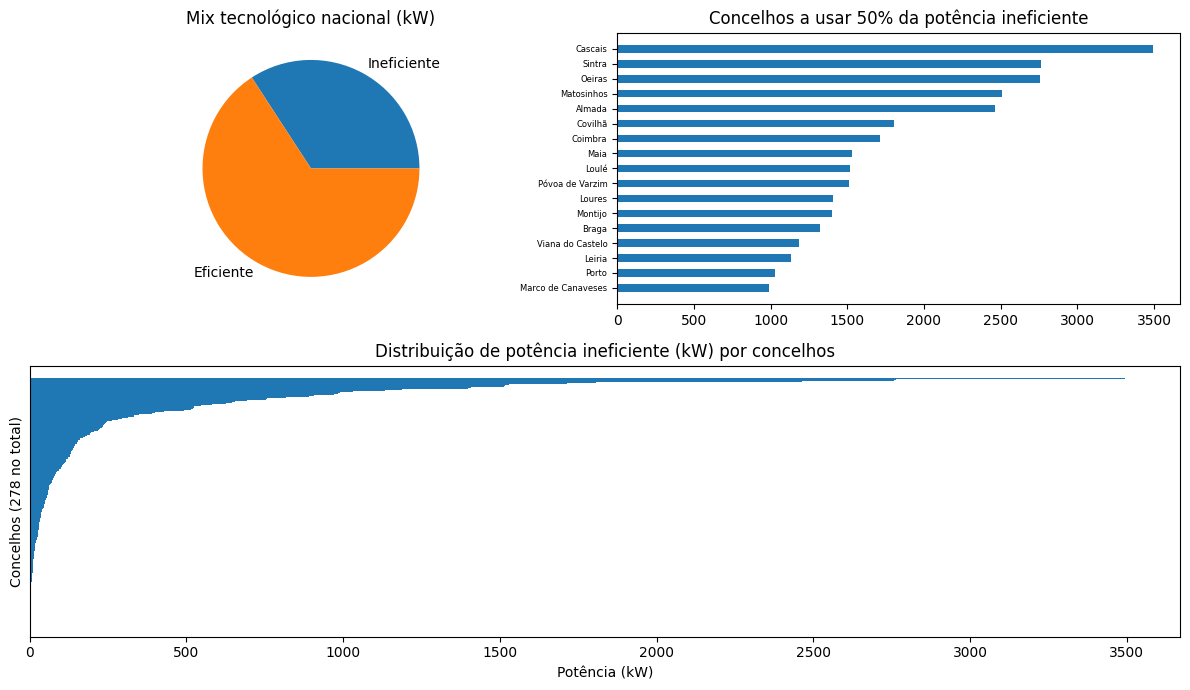

In [39]:
plt.figure(dpi=100, figsize=(12, 7))

plt.subplot(2, 2, 1)

inefficient = result['P_IP_Inef'].sum()
efficient = result['P_IP_Total'].sum() - inefficient

plt.pie([inefficient, efficient], labels=["Ineficiente", "Eficiente"])
plt.title("Mix tecnológico nacional (kW)")

plt.subplot(2, 2, 2)

df_sorted = result.sort_values('P_IP_Inef', ascending=False)
df_sorted['cumsum_inef'] = (df_sorted['P_IP_Inef'].cumsum() / df_sorted['P_IP_Inef'].sum()) * 100

majority_power = df_sorted[df_sorted['cumsum_inef'] <= 50]['P_IP_Inef'].to_numpy()
majority_names = ["".join(b) for b in df_sorted[df_sorted['cumsum_inef'] <= 50]['Concelhos'].to_numpy()]

plt.barh(majority_names, majority_power, height=0.5)
plt.gca().invert_yaxis()
plt.yticks(fontsize=6)
plt.title("Concelhos a usar 50% da potência ineficiente")

plt.subplot(2, 1, 2)

plt.barh(["".join(b) for b in df_sorted['Concelhos']], df_sorted['P_IP_Inef'].to_numpy(), height=1)
plt.gca().invert_yaxis()
plt.title("Distribuição de potência ineficiente (kW) por concelhos")
plt.yticks([])
plt.ylabel("Concelhos (278 no total)")
plt.xlabel("Potência (kW)")

plt.tight_layout()
plt.show()

Os dados revelam que, á escala nacional, tem sido feito muito progresso na otimização da rede de iluminação pública, com uma grande maioria da potência elétrica usada na mesma sendo agora usada para meios de iluminação eficientes, em particular LEDs. No entanto, esta transição continua incompleta: Quase um terço da potência elétrica usada para iluminação pública á escala nacional continua a ser utilizada de um modo ineficiente, e, notavelmente, este uso encontra-se concentrado num grupo muito reduzido de concelhos. Um grupo de apenas 17 concelhos de um total de 278 usam 50% de toda esta "potência ineficiente" nacional.

Outro detalhe importante de notar é que a maioria destes concelhos são zonas urbanizadas, ou que fazem parte de uma grande área metropolitana. Isto pode indicar um maior potencial para a instalação de infraestrutura para carga de VEs: As redes elétricas não teriam de ser adaptadas para redirecionar a potência libertada para um local distante, pois a própria libertação de potência acontece onde estações de carga de VEs são mais necessárias.


Rácio de Ineficiência por Distrito
                  P_IP_Inef  P_IP_Total  Pct_Inef
Distrito                                         
Faro                 6241.9     12716.4      49.1
Castelo Branco       3308.3      6987.8      47.3
Setúbal              5243.6     11268.3      46.5
Viana do Castelo     2977.0      6623.9      44.9
Braga                5786.9     13338.6      43.4
Porto                9121.3     23726.9      38.4
Coimbra              3204.0      8860.3      36.2
Lisboa              12261.7     34374.6      35.7
Leiria               3097.0      9579.9      32.3
Vila Real            1499.9      5466.1      27.4
Santarém             2396.5      9153.3      26.2
Viseu                2158.2      9636.6      22.4
Guarda               1066.4      5586.8      19.1
Aveiro               2289.4     12023.4      19.0
Beja                  382.5      2444.8      15.6
Portalegre            217.2      2425.4       9.0
Évora                 184.3      2127.4       8.7
Bragança      

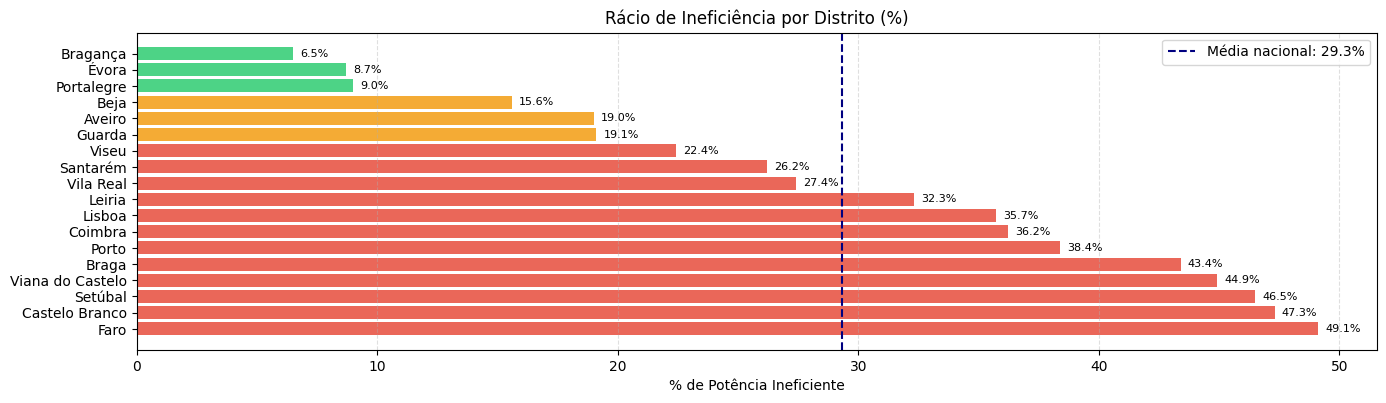

In [40]:
# Adicionar código de distrito ao result
result_plot = result.copy()
result_plot['CodDistrito'] = result_plot.index // 100

mapa_distritos_pt = {
    1: 'Aveiro', 2: 'Beja', 3: 'Braga', 4: 'Bragança', 5: 'Castelo Branco',
    6: 'Coimbra', 7: 'Évora', 8: 'Faro', 9: 'Guarda', 10: 'Leiria',
    11: 'Lisboa', 12: 'Portalegre', 13: 'Porto', 14: 'Santarém',
    15: 'Setúbal', 16: 'Viana do Castelo', 17: 'Vila Real', 18: 'Viseu'
}
result_plot['Distrito'] = result_plot['CodDistrito'].map(mapa_distritos_pt)
result_plot['P_IP_Inef'] = pd.to_numeric(result_plot['P_IP_Inef'], errors='coerce').fillna(0)
result_plot['P_IP_Total'] = pd.to_numeric(result_plot['P_IP_Total'], errors='coerce').fillna(0)

por_distrito = result_plot.groupby('Distrito')[['P_IP_Inef', 'P_IP_Total']].sum()
por_distrito['P_IP_Ef'] = por_distrito['P_IP_Total'] - por_distrito['P_IP_Inef']
por_distrito['Pct_Inef'] = (por_distrito['P_IP_Inef'] / por_distrito['P_IP_Total'] * 100).round(1)
por_distrito = por_distrito.sort_values('Pct_Inef', ascending=False)

fig = plt.figure(figsize=(16, 14), dpi=100)

# Barras de % ineficiência por distrito
ax3 = fig.add_subplot(3, 2, (3, 4))
cores_bar = ['#e74c3c' if p > 20 else '#f39c12' if p > 10 else '#2ecc71'
             for p in por_distrito['Pct_Inef']]
bars = ax3.barh(por_distrito.index, por_distrito['Pct_Inef'], color=cores_bar, alpha=0.85)
ax3.set_xlabel("% de Potência Ineficiente")
ax3.set_title("Rácio de Ineficiência por Distrito (%)")
ax3.axvline(x=por_distrito['Pct_Inef'].mean(), color='navy', linestyle='--',
            linewidth=1.5, label=f"Média nacional: {por_distrito['Pct_Inef'].mean():.1f}%")
for bar, val in zip(bars, por_distrito['Pct_Inef']):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8)
ax3.legend()
ax3.grid(axis='x', linestyle='--', alpha=0.4)

# Resumo por distrito
print("\nRácio de Ineficiência por Distrito")
print(por_distrito[['P_IP_Inef', 'P_IP_Total', 'Pct_Inef']].to_string(
    float_format="{:.1f}".format
))

### 4.3.2


Construa boxplots para comparar as distribuições dos níveis de utilização dos PTDs entre os distritos de Lisboa, Porto, Aveiro e Setúbal. Identifique o distrito com maior variabilidade de carga.

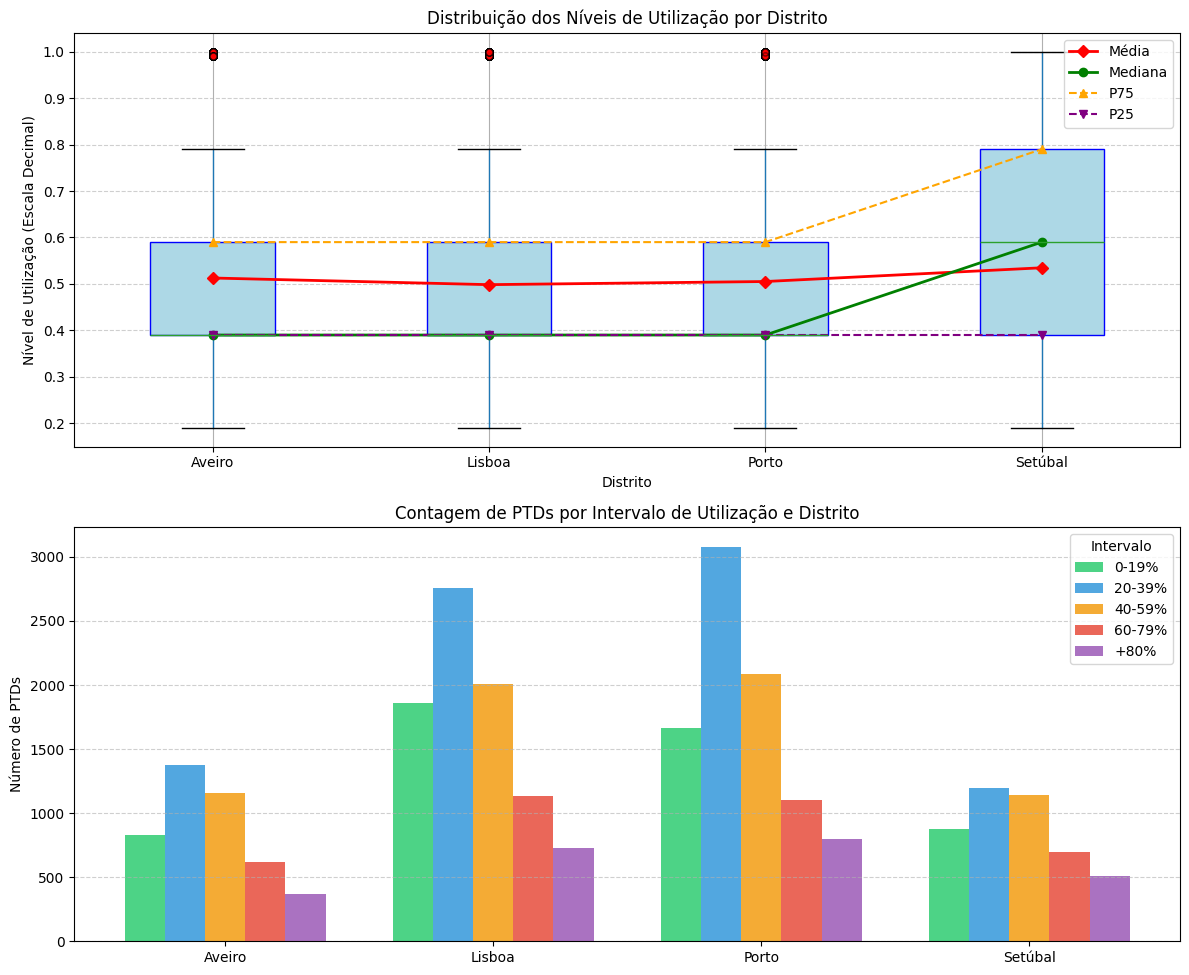

Variabilidade de Carga (Desvio Padrão)
Distrito
Aveiro    0.2379
Lisboa    0.2429
Porto     0.2395
Setúbal   0.2540

Conclusão: O distrito com maior variabilidade de carga é SETÚBAL com um desvio padrão de 0.2540.


In [41]:
# Limpar os NaNs primeiro para não dar erro no matplotlib
ptd_clean = ptd_data.dropna(subset=["Nível de Utilização [%]"]).copy()

ptd_clean["CodDistrito"] = ptd_clean["CodDistritoConcelho"] // 100
mapa_distritos = {1: 'Aveiro', 11: 'Lisboa', 13: 'Porto', 15: 'Setúbal'}

ptd_alvo = ptd_clean[ptd_clean["CodDistrito"].isin(mapa_distritos.keys())].copy()
ptd_alvo["Distrito"] = ptd_alvo["CodDistrito"].map(mapa_distritos)

distritos = sorted(mapa_distritos.values())
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

ax = axes[0]
ptd_alvo.boxplot(
    column="Nível de Utilização [%]",
    by="Distrito",
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5)
)
stats_por_distrito = ptd_alvo.groupby("Distrito")["Nível de Utilização [%]"].agg([
    ('media',   'mean'),
    ('p25',     lambda x: x.quantile(0.25)),
    ('p75',     lambda x: x.quantile(0.75)),
    ('mediana', 'median'),
]).loc[distritos]
x = range(1, len(stats_por_distrito) + 1)
ax.plot(x, stats_por_distrito['media'],   color='red',    marker='D', linewidth=2,   label='Média')
ax.plot(x, stats_por_distrito['mediana'], color='green',  marker='o', linewidth=2,   label='Mediana')
ax.plot(x, stats_por_distrito['p75'],     color='orange', marker='^', linewidth=1.5, linestyle='--', label='P75')
ax.plot(x, stats_por_distrito['p25'],     color='purple', marker='v', linewidth=1.5, linestyle='--', label='P25')
ax.legend(loc='upper right')
ax.set_title('Distribuição dos Níveis de Utilização por Distrito')
ax.set_ylabel('Nível de Utilização (Escala Decimal)')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.suptitle('')

ax2 = axes[1]

# Mapear o valor decimal de volta ao label original (ex: 0.79 -> "60%-79%")
bins   = [0, 0.19, 0.39, 0.59, 0.79, 1.0]
labels = ['0-19%', '20-39%', '40-59%', '60-79%', '+80%']
ptd_alvo["Intervalo"] = pd.cut(ptd_alvo["Nível de Utilização [%]"], bins=bins, labels=labels)

contagens = ptd_alvo.groupby(["Distrito", "Intervalo"], observed=True).size().unstack(fill_value=0)
contagens = contagens.loc[distritos]

x = np.arange(len(distritos))
width = 0.15
cores = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']

for i, (intervalo, cor) in enumerate(zip(labels, cores)):
    ax2.bar(x + i * width, contagens[intervalo], width=width, label=intervalo, color=cor, alpha=0.85)

ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(distritos)
ax2.set_title('Contagem de PTDs por Intervalo de Utilização e Distrito')
ax2.set_ylabel('Número de PTDs')
ax2.legend(title='Intervalo', loc='upper right')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

variabilidade = ptd_alvo.groupby("Distrito")["Nível de Utilização [%]"].std(ddof=1)

distrito_max_var = variabilidade.idxmax()
valor_max_var = variabilidade.max()

print("Variabilidade de Carga (Desvio Padrão)")
print(variabilidade.to_string(float_format="{:.4f}".format))
print(f"\nConclusão: O distrito com maior variabilidade de carga é {distrito_max_var.upper()} com um desvio padrão de {valor_max_var:.4f}.")

Entre os distritos em questão, o distrito com maior variabilidade no nível de utilização de PTDs é Setúbal. Isto sugere uma heterogeneidade no gasto de potência elétrica na iluminação pública ao longo do distrito, e sugere que o planeamento de potenciais estações de carga de VEs pode exigir um maior rigor para acontar com esta realidade.

### 4.3.3

Quantifique a prevalência de valores omissos ou indeterminados (N/D, <20). Utilize uma representação gráfica para identificar a presença de outliers nos níveis de ocupação da rede.

Prevalência de valores omissos/indeterminados
Total de PTDs:                          72027
Valores NaN (N/D):                      3064
Valores Indeterminados (<20%):          14338
Total Omissos/Indeterminados:           17402 (24.16%)

Outliers: PTDs em sobrecarga (+100%)
PTDs em sobrecarga:                     2223 (3.09%)


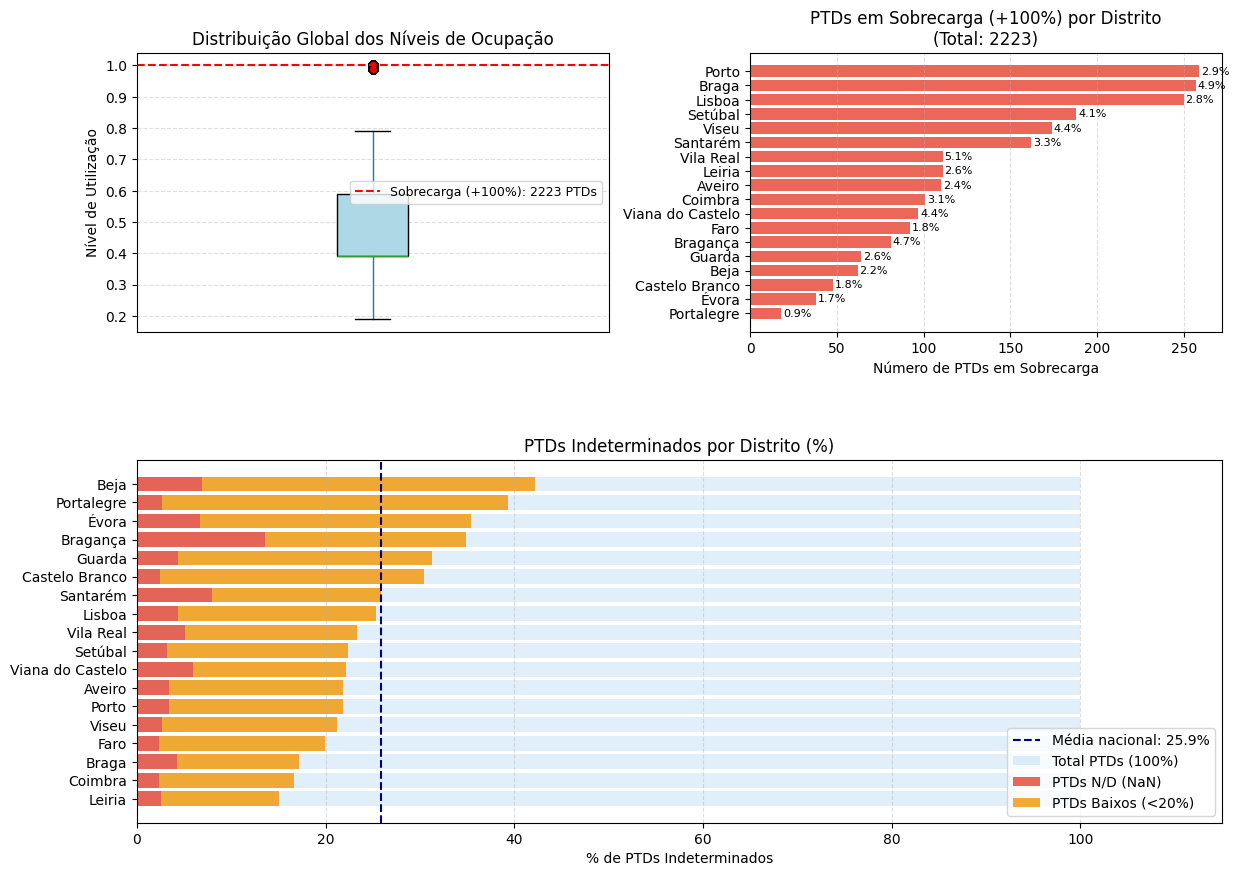

Foram identificados 2223 PTDs em sobrecarga (3.09% da rede).
Estes postos não têm qualquer folga disponível, inviabilizando a instalação de
carregadores VE sem expansão prévia da capacidade instalada.


In [79]:
# Quantificar valores omissos/indeterminados e outliers (PTDs em sobrecarga)
total_registos = len(ptd_data)

distrito_map = {
    1: 'Aveiro', 2: 'Beja', 3: 'Braga', 4: 'Bragança', 5: 'Castelo Branco',
    6: 'Coimbra', 7: 'Évora', 8: 'Faro', 9: 'Guarda', 10: 'Leiria',
    11: 'Lisboa', 12: 'Portalegre', 13: 'Porto', 14: 'Santarém',
    15: 'Setúbal', 16: 'Viana do Castelo', 17: 'Vila Real', 18: 'Viseu'
}
ptd_distritos = ptd_data.groupby(ptd_data['CodDistritoConcelho'] // 100)
distrito_valores_nan = ptd_distritos['Nível de Utilização [%]'].apply(lambda x: x.isna().sum())
distrito_valores_baixos = ptd_distritos.apply(lambda x: (x['Nível de Utilização [%]'] < 0.20).sum())
distrito_valores_indeterminados = distrito_valores_nan + distrito_valores_baixos

valores_nan = ptd_data['Nível de Utilização [%]'].isna().sum()
valores_baixos = ptd_data[ptd_data['Nível de Utilização [%]'] < 0.20].shape[0]
valores_indeterminados  = valores_nan + valores_baixos
ptds_sobrecarga = ptd_data[ptd_data['Nível de Utilização [%]'] >= 1.0]
n_sobrecarga = len(ptds_sobrecarga)

print(f"Prevalência de valores omissos/indeterminados")
print(f"Total de PTDs:                          {total_registos}")
print(f"Valores NaN (N/D):                      {valores_nan}")
print(f"Valores Indeterminados (<20%):          {valores_baixos}")
print(f"Total Omissos/Indeterminados:           {valores_indeterminados} ({valores_indeterminados/total_registos*100:.2f}%)")
print(f"\nOutliers: PTDs em sobrecarga (+100%)")
print(f"PTDs em sobrecarga:                     {n_sobrecarga} ({n_sobrecarga/total_registos*100:.2f}%)")

# Fechar a figura anterior e recriar com GridSpec correto
plt.close(fig)
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.3], hspace=0.4, wspace=0.3)

# Recriar ax e ax2 nos slots corretos
ax = fig.add_subplot(gs[0, 0])
ptd_data.boxplot(
    column='Nível de Utilização [%]', vert=True, ax=ax,
    patch_artist=True, boxprops=dict(facecolor="lightblue"),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.6)
)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label=f'Sobrecarga (+100%): {n_sobrecarga} PTDs')
ax.set_title('Distribuição Global dos Níveis de Ocupação')
ax.set_ylabel('Nível de Utilização')
ax.set_xticks([])
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax2 = fig.add_subplot(gs[0, 1])
ax2.barh(sobrecarga_por_distrito['Distrito'], sobrecarga_por_distrito['N_Sobrecarga'],
         color='#e74c3c', alpha=0.85)
ax2.set_title(f'PTDs em Sobrecarga (+100%) por Distrito\n(Total: {n_sobrecarga})')
ax2.set_xlabel('Número de PTDs em Sobrecarga')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
for i, row in sobrecarga_por_distrito.iterrows():
    ax2.annotate(f"{row['Pct']:.1f}%",
                 xy=(row['N_Sobrecarga'], row['Distrito']),
                 xytext=(row['N_Sobrecarga'] + 1, row['Distrito']),
                 va='center', fontsize=8)

# ax3 — linha de baixo, ocupa as duas colunas
# ax3 — linha de baixo, ocupa as duas colunas
ax3 = fig.add_subplot(gs[1, :])

total_por_distrito2 = ptd_data.copy()
total_por_distrito2['CodDistrito'] = total_por_distrito2['CodDistritoConcelho'] // 100
total_counts = total_por_distrito2.groupby('CodDistrito').size().reset_index(name='Total')
total_counts['Distrito'] = total_counts['CodDistrito'].map(mapa_distritos_pt)

indet_por_distrito = ptd_data.copy()
indet_por_distrito['CodDistrito'] = indet_por_distrito['CodDistritoConcelho'] // 100
nan_counts = indet_por_distrito.groupby('CodDistrito')['Nível de Utilização [%]'].apply(
    lambda x: x.isna().sum()
).reset_index(name='NaN_Count')
low_counts = indet_por_distrito[indet_por_distrito['Nível de Utilização [%]'] < 0.20].groupby(
    'CodDistrito'
).size().reset_index(name='Low_Count')

merged = total_counts.merge(nan_counts, on='CodDistrito', how='left')
merged = merged.merge(low_counts, on='CodDistrito', how='left').fillna(0)
merged['Pct_NaN'] = merged['NaN_Count'] / merged['Total'] * 100
merged['Pct_Low'] = merged['Low_Count'] / merged['Total'] * 100
merged['Pct_Indet'] = merged['Pct_NaN'] + merged['Pct_Low']
merged = merged.sort_values('Pct_Indet', ascending=True)

# Barra de fundo — 100% (total)
ax3.barh(merged['Distrito'], [100] * len(merged), color='#3498db', alpha=0.15, label='Total PTDs (100%)')

# Barra NaN — base 0
ax3.barh(merged['Distrito'], merged['Pct_NaN'], color='#e74c3c', alpha=0.85, label='PTDs N/D (NaN)')

# Barra Low — stacked em cima de NaN
ax3.barh(merged['Distrito'], merged['Pct_Low'], left=merged['Pct_NaN'], color='#f39c12', alpha=0.85, label='PTDs Baixos (<20%)')

mean_pct = merged['Pct_Indet'].mean()
ax3.axvline(x=mean_pct, color='navy', linestyle='--', linewidth=1.5,
            label=f'Média nacional: {mean_pct:.1f}%')

ax3.set_xlabel("% de PTDs Indeterminados")
ax3.set_title("PTDs Indeterminados por Distrito (%)")
ax3.legend(loc='lower right')
ax3.grid(axis='x', linestyle='--', alpha=0.4)
ax3.set_xlim(0, 115)

plt.show()

print(f"Foram identificados {n_sobrecarga} PTDs em sobrecarga ({n_sobrecarga/total_registos*100:.2f}% da rede).")
print(f"Estes postos não têm qualquer folga disponível, inviabilizando a instalação de")
print(f"carregadores VE sem expansão prévia da capacidade instalada.")

> A análise de qualidade dos dados revelou uma prevalência de 24.16% (17402 postos) de valores omissos ou indeterminados (classificados com utilização N/D ou com ocupação inferior a 20%). Adicionalmente, a exploração visual através do diagrama boxplot permite identificar a presença de alguns outliers severos no limite superior da distribuição. Fisicamente, estes outliers representam os PTDs que operam em sobrecarga (+100% da sua capacidade nominal). No contexto do planeamento da rede para a Mobilidade Elétrica, é crítica a identificaçãõ destes postos pois representam infraestruturas sem qualquer folga disponível inviabilizando assim a instalação de carregadores para VEs sem expansão prévia da rede elétrica.

### 4.3.4

Construa uma tabela com a média, quartis, desvio padrão, assimetria e curtose do nível de utilização médio para os concelhos de Coimbra, Évora, Braga e Faro (apresente com 4 casas decimais).

In [43]:
# A tua limpeza de dados inicial mantém-se igual (e bem feita!)
df_concelhos = ptd_data[ptd_data['Concelho'].isin(['Coimbra', 'Évora', 'Braga', 'Faro'])].copy()
df_concelhos = df_concelhos.dropna(subset=['Nível de Utilização [%]'])

# Tabela com as funções corretas do scipy
tabela_estatisticas = df_concelhos.groupby('Concelho')['Nível de Utilização [%]'].agg(
    Média='mean',
    Q1=lambda x: x.quantile(0.25),
    Mediana='median',
    Q3=lambda x: x.quantile(0.75),
    Desvio_Padrão='std',
    Assimetria=lambda x: stats.skew(x),
    Curtose=lambda x: stats.kurtosis(x)
)

tabela_estatisticas = tabela_estatisticas.round(4)

print("--- Estatísticas Descritivas do Nível de Utilização dos PTDs ---")
display(tabela_estatisticas)

--- Estatísticas Descritivas do Nível de Utilização dos PTDs ---


,Média,Q1,Mediana,Q3,Desvio_Padrão,Assimetria,Curtose
Concelho,,,,,,,
Braga,0.5423,0.39,0.59,0.79,0.2401,0.4273,-0.7144
Coimbra,0.5406,0.39,0.59,0.79,0.2322,0.2254,-0.7094
Faro,0.5549,0.39,0.59,0.59,0.2126,0.2998,-0.4848
Évora,0.4546,0.19,0.39,0.59,0.2425,0.6659,-0.4334


## 4.4 - Inferência Estatística


### 4.4.1

Considere a base de dados consolidada e selecione aleatoriamente uma amostra de 50 concelhos. Use esta amostra para testar se o nível médio de ocupação da rede é inferior a um patamar de referência (ex: 60\%), verificando previamente a normalidade dos dados.

**Nota:** Vamos definir cada teste como a sua própria função com os seus argumentos de testes para podermos facilmente repetir os testes e validar padrões

**Nota2:** Neste capitulo frequentemente validamos se os dados são normais antes de serem usados, nas situações em que não são poderiamos usar outros testes e outros parametros, mas nesta iteração da pesquisa decidimos lançar uma excepção e ignorar

In [44]:
def test_normalidade(dados: pd.Series, nome: str = "", alpha: float = 0.05, verbose: bool = True) -> bool:
    """
    Verifica a normalidade de uma amostra visualmente e com o teste de Shapiro-Wilk.
    Retorna True se os dados seguem distribuição normal, False caso contrário.
    """
    if verbose:
        # Verificar a normalidade de maneira visual (https://thalesferraz.medium.com/testes-de-normalidade-usando-python-1abddbc9311f)
        fig, ax = plt.subplots(figsize=(6, 4));
        dados.plot(kind='hist', density=True, ax=ax);
        dados.plot(kind='kde', ax=ax);
        ax.set_title(f"Distribuição - {nome}");
        ax.set_xlabel("Valor");
        plt.show();

    shapiro_result = stats.shapiro(dados);
    p_val = shapiro_result.pvalue;

    if verbose:
        print(f"Teste de Shapiro-Wilk: {nome}");
        print(f"Estatística: {shapiro_result.statistic}, p-value: {p_val}");
        if p_val > alpha:
            print("Não se rejeita H0: dados seguem distribuição normal\n");
        else:
            print("Rejeita-se H0: dados não seguem distribuição normal\n");

    return p_val > alpha;

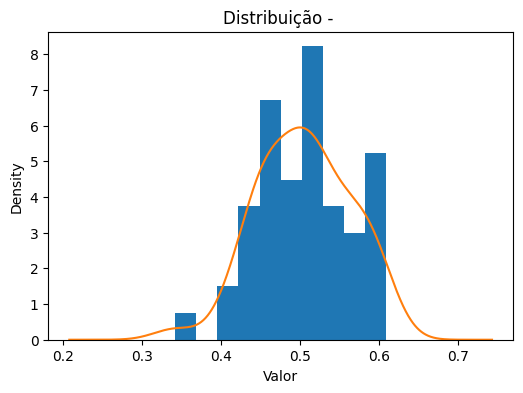

Teste de Shapiro-Wilk: 
Estatística: 0.9783442255949423, p-value: 0.4844433889029821
Não se rejeita H0: dados seguem distribuição normal


Resultado do Teste:
Média da Amostra: 0.5050992846269206
Estatística t: -11.473832597993011
p-value: 8.640360295219758e-16
Rejeita-se H0: ocupação média é inferior a 60%


In [45]:
def teste_ocupação_media_menor_que(p: float = 0.60, s: int = 32, alpha: float = 0.05, verbose: bool = True) -> bool:
    """
    Testa se o nível médio de ocupação da rede é inferior a um patamar de referência.
    Usa uma amostra aleatória de 50 concelhos do dataset ptd_stats.
    Retorna True se não se rejeita H0 (ocupação >= p), False caso contrário.
    """
    amostra_concelhos = ptd_stats.sample(n=50, random_state=s);
    dados_ocupacao = amostra_concelhos['Util_Media'];

    # Verificar normalidade dos dados antes de aplicar o teste t
    norm = test_normalidade(dados_ocupacao, verbose=verbose, alpha=alpha);
    if not norm:
        raise ValueError("Os dados deixaram de ser normais!");

    # H0: media >= p (A ocupação não é inferior ao patamar)
    # H1: media < p  (A ocupação é significativamente inferior ao patamar)
    statistic, pvalue = stats.ttest_1samp(dados_ocupacao, p, alternative='less');

    if verbose:
        print(f"\nResultado do Teste:");
        print(f"Média da Amostra: {dados_ocupacao.mean()}");
        print(f"Estatística t: {statistic}");
        print(f"p-value: {pvalue}");
        if pvalue < alpha:
            print("Rejeita-se H0: ocupação média é inferior a 60%");
        else:
            print("Não se rejeita H0: não há evidência de que ocupação < 60%");

    return pvalue >= alpha;

teste_ocupação_media_menor_que();

### 4.4.2

Selecione aleatoriamente duas amostras de 30 registos: uma de concelhos "Modernizados" (rácio de LED acima da mediana) e outra de concelhos "Ineficientes". Use estas amostras para testar se o estado médio de ocupação da rede difere significativamente entre os dois grupos.

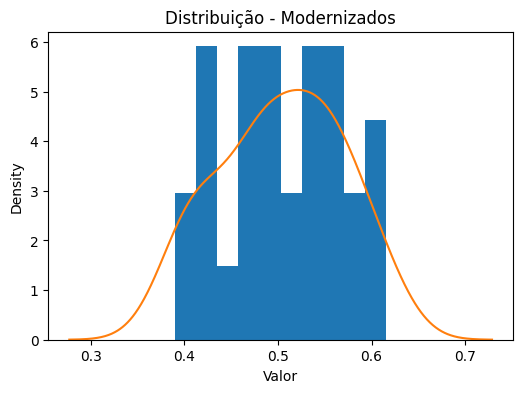

Teste de Shapiro-Wilk: Modernizados
Estatística: 0.9624363698216581, p-value: 0.3569784762486199
Não se rejeita H0: dados seguem distribuição normal



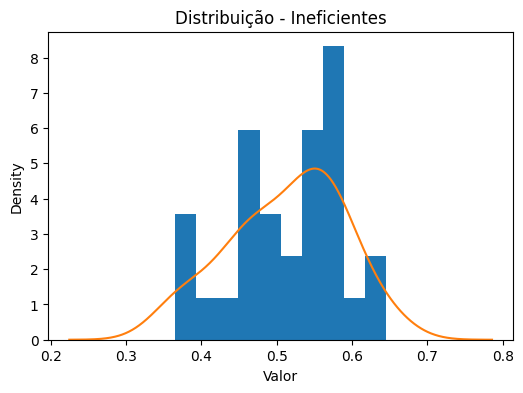

Teste de Shapiro-Wilk: Ineficientes
Estatística: 0.9628045423370845, p-value: 0.36460344700597075
Não se rejeita H0: dados seguem distribuição normal

Teste de Levene: p-value = 0.5015412932866176 -> Variâncias Iguais? True
Média Modernizados:  0.5033953608393146
Média Ineficientes:  0.512790965461672
Estatística: -0.5175314236811901
p-value: 0.6067535672723797
Não se rejeita H0: não há evidência de diferença significativa entre os grupos


In [46]:
def teste_ocupação_media_ef_vs_nef(s: int = 32, alpha: float = 0.05, verbose: bool = True) -> bool:
    """
    Testa se o nível médio de ocupação da rede difere significativamente entre
    concelhos Modernizados (rácio LED acima da mediana) e Ineficientes.
    Usa amostras aleatórias de 30 concelhos de cada grupo.
    Retorna True se não se rejeita H0 (não há diferença), False caso contrário.
    """
    # Juntar Util_Media ao resulting_data para ter tudo num só DataFrame
    combined = resulting_data.join(ptd_stats['Util_Media']);

    # Rate_Ineficiencia abaixo da mediana (menos ineficientes = mais LED)
    mediana_inef = combined['Rate Ineficiencia'].median();
    modernizados = combined[combined['Rate Ineficiencia'] <= mediana_inef];
    ineficientes = combined[combined['Rate Ineficiencia'] > mediana_inef];

    # Amostras de 30 de cada grupo
    amostra_mod  = modernizados.sample(n=30, random_state=s)['Util_Media'];
    amostra_inef = ineficientes.sample(n=30, random_state=s)['Util_Media'];

    # Verificar normalidade de ambos os grupos antes de escolher o teste
    normal_mod  = test_normalidade(amostra_mod,  nome="Modernizados",  alpha=alpha, verbose=verbose);
    normal_inef = test_normalidade(amostra_inef, nome="Ineficientes",  alpha=alpha, verbose=verbose);

    if not normal_mod or not normal_inef:
        raise ValueError("Os dados deixaram de ser normais!");

    _, pval_levene = stats.levene(amostra_mod, amostra_inef)
    variancias_iguais = pval_levene >= 0.05
    
    if verbose:
        print(f"Teste de Levene: p-value = {pval_levene} -> Variâncias Iguais? {variancias_iguais}")

    # H0: média_modernizados == média_ineficientes (não há diferença)
    # H1: média_modernizados != média_ineficientes (há diferença significativa)
    statistic, pvalue = stats.ttest_ind(amostra_mod, amostra_inef, equal_var=variancias_iguais, alternative='two-sided')

    if verbose:
        print(f"Média Modernizados:  {amostra_mod.mean()}");
        print(f"Média Ineficientes:  {amostra_inef.mean()}");
        print(f"Estatística: {statistic}");
        print(f"p-value: {pvalue}");
        if pvalue < alpha:
            print("Rejeita-se H0: a ocupação média difere significativamente entre os dois grupos");
        else:
            print("Não se rejeita H0: não há evidência de diferença significativa entre os grupos");

    return pvalue >= alpha;

teste_ocupação_media_ef_vs_nef();

> Para avaliar se a modernização da iluminação pública (tecnologia LED) tem um impacto direto no estado global de ocupação da rede, procedeu-se à divisão dos concelhos em dois grupos independentes ('Modernizados' e 'Ineficientes'), utilizando a mediana do rácio de ineficiência como critério de separação. Após a extração de duas amostras aleatórias (n=30) e a validação dos pressupostos de normalidade (Shapiro-Wilk) e homocedasticidade (Teste de Levene), aplicou-se um Teste T para amostras independentes. O resultado obtido (p-value = 0.606) indica que não existe evidência estatística para rejeitar a igualdade das médias (H0). Conclui-se, assim, que a transição para LED, embora liberte potência localizada, não altera de forma estatisticamente significativa o perfil médio de ocupação macro dos PTDs quando comparado com concelhos não modernizados.

### 4.4.3

Considere três amostras aleatórias de 25 concelhos representativas de diferentes perfis de ocupação da rede: Norte/Centro Litoral (Porto, Braga, Coimbra), Lisboa e Litoral Sul (Lisboa, Setúbal, Aveiro) e Interior/Alentejo (Évora, Beja, Portalegre). Use estas amostras para testar a existência de diferenças significativas nos níveis médios de carga da rede (ANOVA). Caso necessário, efetue uma análise post-hoc adequada

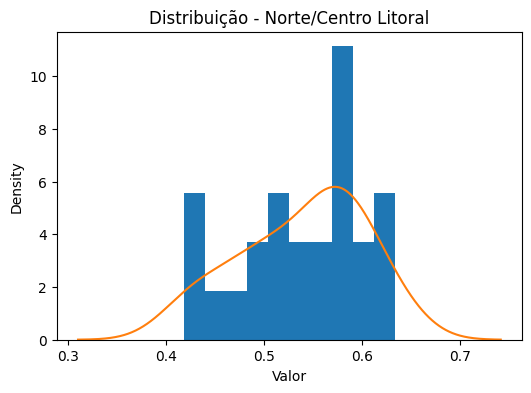

Teste de Shapiro-Wilk: Norte/Centro Litoral
Estatística: 0.9476374677273189, p-value: 0.22166352182737364
Não se rejeita H0: dados seguem distribuição normal



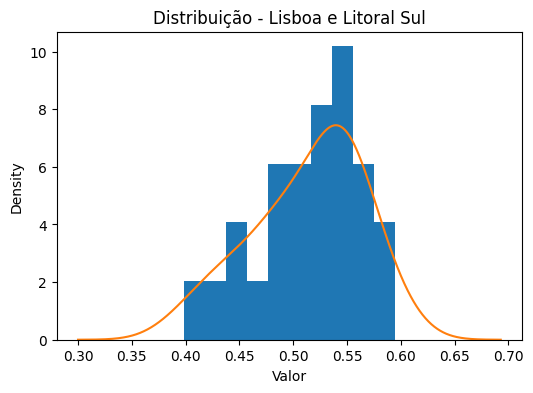

Teste de Shapiro-Wilk: Lisboa e Litoral Sul
Estatística: 0.9531984035075829, p-value: 0.29560899848696154
Não se rejeita H0: dados seguem distribuição normal



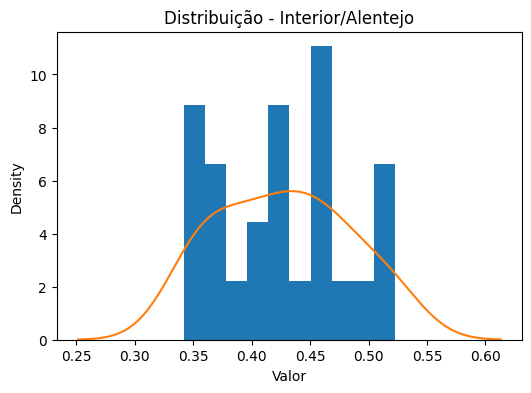

Teste de Shapiro-Wilk: Interior/Alentejo
Estatística: 0.9528986694047112, p-value: 0.29111779911469227
Não se rejeita H0: dados seguem distribuição normal

Teste de Levene: p-value = 0.5516
Decisão Levene: Não se rejeita H0 (Variâncias são homogéneas). Pressuposto validado!


ANOVA de um fator
Média Norte/Centro Litoral:  0.5384433112329866
Média Lisboa e Litoral Sul:  0.5131474345178243
Média Interior/Alentejo:     0.4272981768170115
Estatística F: 26.162369310051815
p-value: 2.8833535450362094e-09
Rejeita-se H0: existem diferenças significativas entre as regiões

Análise Post-hoc de Tukey
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower  upper  reject
------------------------------------------------------------------
      Interior Lisboa/Litoral   0.0858   0.0  0.0473 0.1244   True
      Interior   Norte/Centro   0.1111   0.0  0.0726 0.1497   True
Lisboa/Litoral   Norte/Centro   0.0253 0.265 -0.0133 0.0638  False


In [47]:
def teste_anova_regioes(s: int = 32, alpha: float = 0.05, verbose: bool = True) -> bool:
    """
    Testa se existem diferenças significativas no nível médio de ocupação da rede
    entre três regiões: Norte/Centro Litoral, Lisboa e Litoral Sul, e Interior/Alentejo.
    Usa amostras aleatórias de 25 concelhos por região.
    Retorna True se não se rejeita H0 (não há diferença), False caso contrário.
    Caso H0 seja rejeitado, aplica análise post-hoc de Tukey.
    """
    combined = resulting_data.join(ptd_stats['Util_Media']).reset_index();

    # Códigos de distrito por região
    distritos_norte_centro =    [6, 3, 13];   # Coimbra, Braga, Porto
    distritos_lisboa_litoral =  [11, 15, 1];  # Lisboa, Setúbal, Aveiro
    distritos_interior =        [7, 2, 12];   # Évora, Beja, Portalegre

    # Cada código de concelho começa com o código do distrito (primeiros 2 dígitos)
    norte_centro   = combined[(combined['CodDistritoConcelho'] // 100).isin(distritos_norte_centro)];
    lisboa_litoral = combined[(combined['CodDistritoConcelho'] // 100).isin(distritos_lisboa_litoral)];
    interior       = combined[(combined['CodDistritoConcelho'] // 100).isin(distritos_interior)];

    # Amostras de 25 concelhos por região
    amostra_norte =    norte_centro.sample(n=25, random_state=s)['Util_Media'];
    amostra_lisboa =   lisboa_litoral.sample(n=25, random_state=s)['Util_Media'];
    amostra_interior = interior.sample(n=25, random_state=s)['Util_Media'];

    # Verificar normalidade de cada grupo — ANOVA assume normalidade
    normal_norte    = test_normalidade(amostra_norte, nome="Norte/Centro Litoral", alpha=alpha, verbose=verbose);
    normal_lisboa   = test_normalidade(amostra_lisboa, nome="Lisboa e Litoral Sul", alpha=alpha, verbose=verbose);
    normal_interior = test_normalidade(amostra_interior,nome="Interior/Alentejo", alpha=alpha, verbose=verbose);

    if not normal_norte or not normal_lisboa or not normal_interior:
        raise ValueError("Os dados deixaram de ser normais!");

    _, pval_levene = stats.levene(amostra_norte, amostra_lisboa, amostra_interior)
    if verbose:
        print(f"Teste de Levene: p-value = {pval_levene:.4f}")
        if pval_levene >= alpha:
            print("Decisão Levene: Não se rejeita H0 (Variâncias são homogéneas). Pressuposto validado!\n")
        else:
            print("Decisão Levene: Rejeita-se H0 (Variâncias diferem). AVISO: A ANOVA pode perder robustez.\n")

    # H0: média_norte == média_lisboa == média_interior (não há diferença entre regiões)
    # H1: pelo menos uma região difere significativamente das restantes
    result = stats.f_oneway(amostra_norte, amostra_lisboa, amostra_interior);

    if verbose:
        print(f"\nANOVA de um fator");
        print(f"Média Norte/Centro Litoral:  {amostra_norte.mean()}");
        print(f"Média Lisboa e Litoral Sul:  {amostra_lisboa.mean()}");
        print(f"Média Interior/Alentejo:     {amostra_interior.mean()}");
        print(f"Estatística F: {result.statistic}");
        print(f"p-value: {result.pvalue}");

        if result.pvalue < alpha:
            print("Rejeita-se H0: existem diferenças significativas entre as regiões");

            # Análise post-hoc de Tukey para identificar quais pares diferem
            valores  = np.concatenate([amostra_norte, amostra_lisboa, amostra_interior]);
            grupos   = (["Norte/Centro"] * len(amostra_norte) +
                        ["Lisboa/Litoral"] * len(amostra_lisboa) +
                        ["Interior"] * len(amostra_interior));

            tukey = pairwise_tukeyhsd(valores, grupos, alpha=alpha);
            print(f"\nAnálise Post-hoc de Tukey");
            print(tukey);
        else:
            print("Não se rejeita H0: não há evidência de diferenças significativas entre as regiões");

    return result.pvalue >= alpha;

teste_anova_regioes();

> Para avaliar disparidades regionais na ocupação da rede elétrica, conduziu-se uma Análise de Variância de um fator (One-Way ANOVA) comparando três macro-regiões (Norte/Centro Litoral, Lisboa/Litoral Sul e Interior/Alentejo). Após a validação dos pressupostos de normalidade (Shapiro-Wilk) e homogeneidade de variâncias (Teste de Levene), o teste ANOVA revelou diferenças estatisticamente muito significativas entre os grupos (F = 26.16, p-value < 0.001). >
Para identificar a origem destas diferenças, aplicou-se o teste post-hoc de Tukey HSD. Os resultados demonstraram que a região do Interior/Alentejo apresenta um nível médio de ocupação (42.7%) estatisticamente inferior a ambas as regiões litorais (Norte/Centro com 53.8% e Lisboa/Sul com 51.3%). Em contrapartida, não foi detetada qualquer diferença estatística significativa (p-adj = 0.265) entre as duas regiões litorais. Conclui-se, do ponto de vista do planeamento de rede, que os PTDs do interior do país possuem uma margem de folga substancialmente maior, apresentando condições infraestruturais mais favoráveis para a absorção imediata de carga proveniente de novos carregadores VE sem necessidade de expansão prévia da rede.

### 4.4.4

Teste a existência de uma relação linear estatisticamente significativa entre a capacidade total de transformação instalada e a carga de iluminação pública para a totalidade dos concelhos, interpretando o coeficiente de correlação de Pearson

In [48]:
def teste_correlacao_pearson(alpha: float = 0.05, verbose: bool = True) -> bool:
    """
    Testa a existência de uma relação linear estatisticamente significativa
    entre a capacidade total de transformação instalada (Cap_PTD) e a carga
    de iluminação pública (P_IP_Total) para a totalidade dos concelhos.
    Retorna True se não se rejeita H0 (não há correlação), False caso contrário.
    """
    combined = result.join(ptd_stats['Cap_PTD']);

    cap_ptd   = combined['Cap_PTD'];
    p_ip_total = combined['P_IP_Total'];

    # H0: rho == 0 (não existe relação linear entre as variáveis)
    # H1: rho != 0 (existe relação linear estatisticamente significativa)
    statistic, pvalue = stats.pearsonr(cap_ptd, p_ip_total);

    if verbose:
        print(f"\nCorrelação de Pearson");
        print(f"Coeficiente r: {statistic}");
        print(f"p-value: {pvalue}");

        # Interpretar a força da correlação
        r = abs(statistic);
        if r < 0.2:
            forca = "muito fraca";
        elif r < 0.4:
            forca = "fraca";
        elif r < 0.6:
            forca = "moderada";
        elif r < 0.8:
            forca = "forte";
        else:
            forca = "muito forte";

        direcao = "positiva" if statistic > 0 else "negativa";
        print(f"Interpretação: correlação {forca} e {direcao}");

        if pvalue < alpha:
            print("Rejeita-se H0: existe relação linear significativa entre Cap_PTD e P_IP_Total");
        else:
            print("Não se rejeita H0: não há evidência de relação linear significativa");

    return pvalue >= alpha;

teste_correlacao_pearson();


Correlação de Pearson
Coeficiente r: 0.9110858281637024
p-value: 3.132394344687929e-108
Interpretação: correlação muito forte e positiva
Rejeita-se H0: existe relação linear significativa entre Cap_PTD e P_IP_Total


> Para avaliar a associação entre a infraestrutura de transformação e o consumo de iluminação pública, aplicou-se o teste de correlação linear de Pearson à totalidade dos concelhos. Os resultados revelaram uma correlação positiva muito forte e estatisticamente significativa ($r = 0.911$, p-value < 0.001) entre a Capacidade Total de Transformação (Cap_PTD) e a Potência Total de Iluminação Pública (P_IP_Total). Elevando o coeficiente de correlação ao quadrado ($r^2 \approx 0.83$), conclui-se que aproximadamente 83% da variabilidade da carga de iluminação pública pode ser explicada pela capacidade instalada dos PTDs locais. Esta forte colinearidade era expectável, refletindo o dimensionamento macro da rede elétrica em função da dimensão demográfica e urbana de cada município.

### Testar com várias seeds

A maneira como arquitecturamos estes testes (ver nota no topo do capítulo) vais ons permitir retestar tudo com várias seeds para ter uma melhor visão da variabilidade desta informação

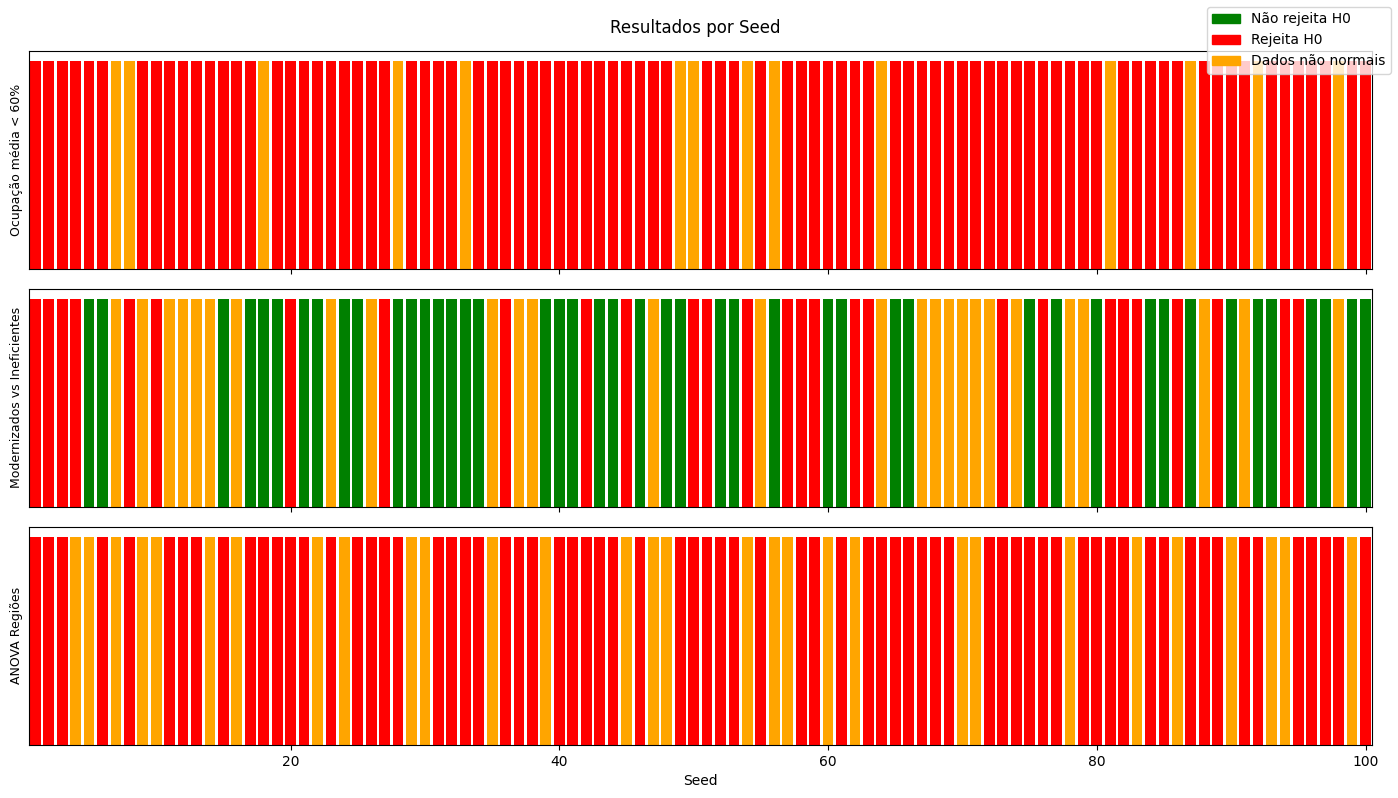

teste_ocupação_media_menor_que:
	Não rejeita H0:   0/100 (0.0%)
	Rejeita H0:       86/100 (86.0%)
	Dados não normais:14/100 (14.0%)

teste_ocupação_media_ef_vs_nef:
	Não rejeita H0:   45/100 (45.0%)
	Rejeita H0:       28/100 (28.0%)
	Dados não normais:27/100 (27.0%)

teste_anova_regioes:
	Não rejeita H0:   0/100 (0.0%)
	Rejeita H0:       70/100 (70.0%)
	Dados não normais:30/100 (30.0%)



In [49]:
def testar_seeds(seeds: range = range(1, 101), alpha: float = 0.05) -> None:
    """
    Corre as três funções de teste para várias seeds e mostra um gráfico
    com os resultados (Rejeita/Não rejeita H0 / Dados não normais) para cada seed.
    """
    # None = dados não normais
    resultados = {
        "teste_ocupação_media_menor_que": [],
        "teste_ocupação_media_ef_vs_nef": [],
        "teste_anova_regioes": []
    };

    for s in seeds:
        for nome, func in [
            ("teste_ocupação_media_menor_que", lambda s: teste_ocupação_media_menor_que(s=s, alpha=alpha, verbose=False)),
            ("teste_ocupação_media_ef_vs_nef", lambda s: teste_ocupação_media_ef_vs_nef(s=s, alpha=alpha, verbose=False)),
            ("teste_anova_regioes",            lambda s: teste_anova_regioes(s=s, alpha=alpha, verbose=False)),
        ]:
            try:
                resultados[nome].append(func(s));
            except ValueError:
                resultados[nome].append(None); # dados não normais

    # Gráfico
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True);

    titulos = [
        "Ocupação média < 60%",
        "Modernizados vs Ineficientes",
        "ANOVA Regiões"
    ];

    def cor(v):
        if v is None: return "orange";
        return "green" if v else "red";

    for ax, (nome, valores), titulo in zip(axes, resultados.items(), titulos):
        cores = [cor(v) for v in valores];
        ax.bar(list(seeds), [1] * len(seeds), color=cores, width=0.8);
        ax.set_ylabel(titulo, fontsize=9);
        ax.set_yticks([]);
        ax.set_xlim(min(seeds) - 0.5, max(seeds) + 0.5);

    # Legenda
    from matplotlib.patches import Patch;
    legenda = [
        Patch(color="green",  label="Não rejeita H0"),
        Patch(color="red",    label="Rejeita H0"),
        Patch(color="orange", label="Dados não normais"),
    ];
    fig.legend(handles=legenda, loc="upper right");
    fig.suptitle("Resultados por Seed", fontsize=12);
    axes[-1].set_xlabel("Seed");
    plt.tight_layout();
    plt.show();

    # Resumo
    for nome, valores in resultados.items():
        total    = len(valores);
        rejeita  = sum(1 for v in valores if v == False and v is not None)
        nao_rej  = sum(1 for v in valores if v == True  and v is not None)
        nao_norm = sum(1 for v in valores if v is None)
        print(f"{nome}:");
        print(f"\tNão rejeita H0:   {nao_rej}/{total} ({nao_rej/total*100:.1f}%)");
        print(f"\tRejeita H0:       {rejeita}/{total} ({rejeita/total*100:.1f}%)");
        print(f"\tDados não normais:{nao_norm}/{total} ({nao_norm/total*100:.1f}%)\n");

testar_seeds();

## 4.5 - Correlação e Regressão - Modelo Preditivo


Considere os dados relativos aos níveis médios de carga dos PTDs nos distritos de Aveiro, Porto, Lisboa e Braga e construa uma tabela de correlação entre as principais métricas de infraestrutura (Capacidade PTD e Potência IP) para estes distritos. Selecione os dados relativos a Portugal Continental. Considere as seguintes variáveis explicativas:

- X1 – Potência Instalada Total de Iluminação Pública ***(P_IP_Total)***
- X2 – Capacidade Nominal de Transformação ***(Cap_PTD)***
- X3 – Ineficiência ***(Rate_Ineficencia)***

e a variável dependente:

- Y – Estado de Ocupação Médio da Rede ***(Util_Media)***.

In [50]:
# Juntar as métricas de infraestrutura num DataFrame
df_corr = pd.concat([
    result['P_IP_Total'],
    ptd_stats['Cap_PTD']
], axis=1)

df_corr['P_IP_Total'] = pd.to_numeric(df_corr['P_IP_Total'], errors='coerce')

# Obter o código do distrito a partir do index
df_corr['CodDistrito'] = df_corr.index // 100

# Filtrar apenas para Aveiro (1), Braga (3), Lisboa (11) e Porto (13)
distritos_alvo = [1, 3, 11, 13]
df_filtrado = df_corr[df_corr['CodDistrito'].isin(distritos_alvo)].copy()

# Remover NaNs porque não interessan
df_filtrado = df_filtrado.dropna(subset=['P_IP_Total', 'Cap_PTD'])

# Calcular a Matriz de Correlação de Pearson
matriz_correlacao = df_filtrado[['P_IP_Total', 'Cap_PTD']].corr()

df_reg = pd.concat([
    result['P_IP_Total'],                  # X1
    ptd_stats[['Cap_PTD', 'Util_Media']],  # X2 e Y
    resulting_data['Rate Ineficiencia']    # X3
], axis=1)

# Converter para numérico por segurança
df_reg['P_IP_Total'] = pd.to_numeric(df_reg['P_IP_Total'], errors='coerce')
df_reg['Rate Ineficiencia'] = pd.to_numeric(df_reg['Rate Ineficiencia'], errors='coerce')

# Aveiro (1), Braga (3), Lisboa (11), Porto (13)
distritos_selecionados = [1, 3, 11, 13]
df_reg['CodDistrito'] = df_reg.index // 100
df_final = df_reg[df_reg['CodDistrito'].isin(distritos_selecionados)].copy()

# Limpar NaNs para o cálculo não falhar
df_final = df_final.dropna(subset=['Util_Media', 'P_IP_Total', 'Cap_PTD', 'Rate Ineficiencia'])

print(df_final)

                      P_IP_Total  Cap_PTD  Util_Media  Rate Ineficiencia  \
CodDistritoConcelho                                                        
101                   910.887701   105715    0.477593           0.268222   
102                   451.711801    54540    0.469948           0.062031   
103                   657.071801    55628    0.543009           0.111928   
104                   585.974400    41884    0.527387           0.197483   
105                  1055.192001   197485    0.475475           0.136866   
...                          ...      ...         ...                ...   
1314                  799.513600   110070    0.566979           0.414965   
1315                 1756.744600   188930    0.489684           0.018364   
1316                 1112.312900   173155    0.511842           0.053636   
1317                 2324.996099   763920    0.417874           0.059235   
1318                  503.720400    84735    0.513430           0.262308   

           

### 4.5.1

Determine o modelo de regressão linear múltipla que explique a variação de Y em função de X1, X2 e X3.

In [51]:
# Definir X e Y
Y = df_final['Util_Media']
X = df_final[['P_IP_Total', 'Cap_PTD', 'Rate Ineficiencia']]

# Adicionar a constante (Intercepto Beta_0)
X_com_const = sm.add_constant(X)

modelo = sm.OLS(Y, X_com_const).fit()

# Mostrar resultados
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:             Util_Media   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     7.630
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           0.000211
Time:                        08:53:46   Log-Likelihood:                 101.95
No. Observations:                  64   AIC:                            -195.9
Df Residuals:                      60   BIC:                            -187.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5417      0.01

O modelo explica apenas 27.6% da variação de Util_Media (R²=0.276), o que é fraco. Ou seja, 72.4% da variação fica por explicar, há outros fatores importantes que o modelo não inclui. O F-statistic tem p=0.0002, o que significa que o modelo como um todo é estatisticamente significativo, mas isso não compensa o R² baixo.

### 4.5.2

Verifique as condições sobre os resíduos (normalidade, independência e homocedasticidade).

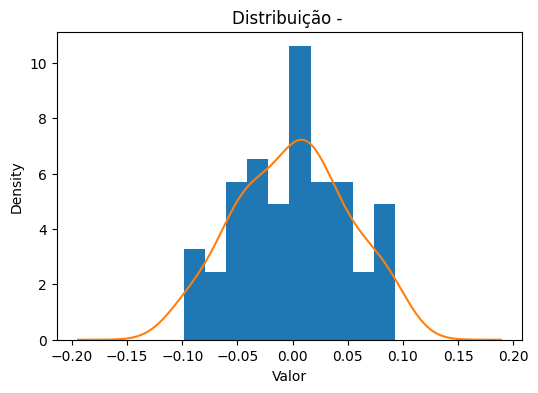

Teste de Shapiro-Wilk: 
Estatística: 0.9795017312794554, p-value: 0.3646079912069631
Não se rejeita H0: dados seguem distribuição normal

Teste de Independência (Durbin-Watson)
Valor DW: 1.8805
Sem evidência de autocorrelação (Independência OK)

Homocedasticidade (Gráfico de Dispersão)


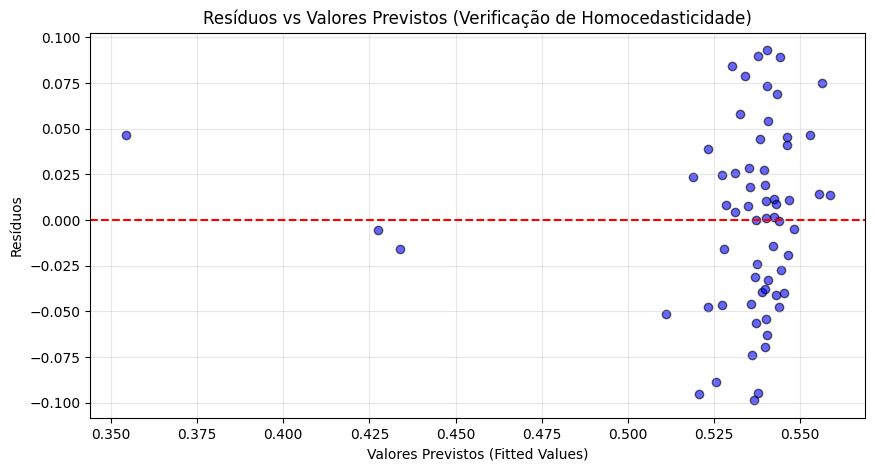

Breusch-Pagan p-value: 0.8682
Não se rejeita H0: variância constante (Homocedasticidade OK)


In [52]:
# Extrair resíduos e valores previstos
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

norm = test_normalidade(residuos);
if not norm:
    raise ValueError("Os dados não são normais");

print(f"Teste de Independência (Durbin-Watson)")
dw = durbin_watson(residuos)
print(f"Valor DW: {dw:.4f}")
if 1.5 < dw < 2.5:
    print("Sem evidência de autocorrelação (Independência OK)\n")
else:
    print("Possível autocorrelação nos resíduos\n")

print(f"Homocedasticidade (Gráfico de Dispersão)")
plt.figure(figsize=(10, 5))

# Gráfico de Resíduos vs Valores Ajustados
plt.scatter(valores_ajustados, residuos, color='blue', alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Previstos (Fitted Values)')
plt.ylabel('Resíduos')
plt.title('Resíduos vs Valores Previstos (Verificação de Homocedasticidade)')
plt.grid(alpha=0.3)
plt.show()

# Teste de Breusch-Pagan
# H0: A variância dos resíduos é constante (homocedasticidade)
# H1: A variância dos resíduos não é constante (heterocedasticidade)
_, p_bp, _, _ = het_breuschpagan(residuos, modelo.model.exog)
print(f"Breusch-Pagan p-value: {p_bp:.4f}")
if p_bp > 0.05:
    print("Não se rejeita H0: variância constante (Homocedasticidade OK)")
else:
    print("Rejeita-se H0: variância não constante (Heterocedasticidade detetada)")

**Nota:** O teste de Breusch-Pagan existe porque o gráfico de resíduos é subjetivo duas pessoas podem olhar para o mesmo gráfico e tirar conclusões diferentes sobre se há ou não um padrão de funil. O Breusch-Pagan formaliza essa análise: internamente, ele faz uma regressão dos resíduos ao quadrado contra as variáveis explicativas do modelo. 

## 4.5.3

Verifique se existe multicolinearidade entre as variáveis recorrendo ao cálculo do VIF *(Variance Inflation Factor)*.

In [53]:
# Calcular o VIF para as variáveis do modelo
# VIF mede o quanto a variância de um coeficiente aumenta devido à correlação com outros preditores
# H0: Não existe multicolinearidade (VIF próximo de 1)
# Regra: VIF > 5 moderada, VIF > 10 severa
vif_df = pd.DataFrame()
vif_df["Variável"] = X_com_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_com_const.values, i) for i in range(X_com_const.shape[1])]

# Filtrar a constante porque o que nos interessa são os preditores
vif_final = vif_df[vif_df['Variável'] != 'const']
print(vif_final.to_string(index=False))

max_vif = vif_final['VIF'].max()
var_max = vif_final.loc[vif_final['VIF'].idxmax(), 'Variável']

if max_vif > 10:
    print(f"\nResultado: '{var_max}' tem VIF = {max_vif}. Multicolinearidade SEVERA (> 10)")
elif max_vif > 5:
    print(f"\nResultado: '{var_max}' tem VIF = {max_vif}. Multicolinearidade Moderada (> 5)")
else:
    print(f"\nResultado: VIF Máximo = {max_vif}. Sem multicolinearidade significativa")

         Variável      VIF
       P_IP_Total 8.392443
          Cap_PTD 7.528046
Rate Ineficiencia 1.442317

Resultado: 'P_IP_Total' tem VIF = 8.392443071820505. Multicolinearidade Moderada (> 5)


## 4.5.4

Comente o modelo obtido tendo em conta o coeficiente de determinação ajustado e a significância estatística dos preditores.

1.) **Coeficiente de Determinação Ajustado ($R^2_{adj} = 0.240$)**

O valor de $R^2$ Ajustado é de 0.240. Isto indica que o modelo consegue explicar 24% da variabilidade da ocupação média da rede (Util_Media) nos distritos de Aveiro, Porto, Lisboa e Braga através das três variáveis independentes escolhidas.
  -Nota Crítica: Embora pareça um valor baixo, em estudos de infraestruturas urbanas é um resultado aceitável, dado que a ocupação de um transformador (PTD) depende de muitos outros fatores que não temos no dataset (como o número de indústrias, centros comerciais ou densidade populacional doméstica).

2.) **Significância Estatística dos Preditores (Análise dos p-values)**

Para um nível de significância de $\alpha = 0.05$ (confiança de 95%), analisamos a coluna P>|t| da tua tabela:
  - Capacidade do PTD (Cap_PTD): Apresenta um $p\text{-value} = 0.005$. Como $0.005 < 0.05$, esta variável é estatisticamente significativa. Ou seja, a capacidade instalada é um preditor real e fiável da ocupação da rede nestes distritos.
  - Potência de Iluminação (P_IP_Total): Apresenta um $p\text{-value} = 0.185$. Como $0.185 > 0.05$, não é significativa para este modelo. Isto sugere que, na presença da capacidade total do PTD, a iluminação pública isolada não acrescenta informação estatística relevante para prever a carga.
  - Rácio de Ineficiência (Rate Ineficiencia): Apresenta um $p\text{-value} = 0.672$. É a variável menos significativa. Isto prova que a percentagem de lâmpadas antigas (Sódio/Mercúrio) não tem impacto direto detetável na ocupação média da rede nestes grandes centros urbanos.

3.) **Significância Global do Modelo (Teste F)** 
O valor de Prob (F-statistic) é 0.000211. Sendo este valor muito inferior a 0.05, podemos afirmar que o modelo, no seu conjunto, é estatisticamente significativo. Pelo menos uma das variáveis independentes ajuda a prever o $Y$ melhor do que se usássemos apenas a média.

### 4.5.5

Estime o nível de ocupação esperado (Y) para os concelhos com os códigos: 101, 102, 103, 104, 105, 106, 107, 108 e 109 (Distrito de Aveiro) e compare as previsões com os valores reais presentes no dataset.

In [54]:
# Estimar o nível de ocupação esperado para os concelhos do Distrito de Aveiro
# e comparar as previsões com os valores reais

concelhos_aveiro = [101, 102, 103, 104, 105, 106, 107, 108, 109]

df_aveiro = df_reg.loc[df_reg.index.isin(concelhos_aveiro)].copy()

X_aveiro_const = sm.add_constant(df_aveiro[['P_IP_Total', 'Cap_PTD', 'Rate Ineficiencia']], has_constant='add')
previsoes = modelo.predict(X_aveiro_const)

comparativo = pd.DataFrame({
    'Real (Y)':          df_aveiro['Util_Media'],
    'Previsão':          previsoes,
    'Resíduo':           df_aveiro['Util_Media'] - previsoes,
    'Erro Absoluto (%)': (abs(df_aveiro['Util_Media'] - previsoes) / df_aveiro['Util_Media']) * 100
}).round(4)

print(comparativo.to_string())

mae = comparativo['Resíduo'].abs().mean()
rmse = (comparativo['Resíduo'] ** 2).mean() ** 0.5
print(f"\nErro Médio Absoluto (MAE):  {mae:.4f}")
print(f"Raiz do Erro Quadrático (RMSE): {rmse:.4f}")

                     Real (Y)  Previsão  Resíduo  Erro Absoluto (%)
CodDistritoConcelho                                                
101                    0.4776    0.5404  -0.0628            13.1593
102                    0.4699    0.5398  -0.0698            14.8536
103                    0.5430    0.5438  -0.0007             0.1371
104                    0.5274    0.5463  -0.0189             3.5909
105                    0.4755    0.5233  -0.0478            10.0636
106                    0.5432    0.5481  -0.0049             0.9030
107                    0.4434    0.5379  -0.0945            21.3125
108                    0.5076    0.5408  -0.0331             6.5286
109                    0.5829    0.5385   0.0444             7.6211

Erro Médio Absoluto (MAE):  0.0419
Raiz do Erro Quadrático (RMSE): 0.0511


Resíduos: todos entre -0.09 e +0.05, ou seja o modelo nunca erra mais que ~9 pontos percentuais. Para um modelo de ocupação de rede isto é aceitável.

Erro Absoluto (%): a maioria está abaixo de 10%, com exceção do concelho 107 (21%) e 101/102 (~13-15%). Estes concelhos têm provavelmente características que o modelo não captura bem com apenas 3 variáveis.

MAE = 0.0419: em média o modelo erra ~4.2 pontos percentuais na ocupação. Dado que os valores reais estão todos entre 0.44 e 0.58, um erro médio de 0.04 representa cerca de 8% da gama de variação.

RMSE = 0.0511: ligeiramente maior que o MAE, o que indica que há alguns erros maiores a puxar a média para cima (os concelhos 107 e 101/102). Mas a diferença entre MAE e RMSE não é dramática, por isso não há outliers graves.

Nota importante: todos os resíduos são negativos exceto o 109, o que significa que o modelo sistematicamente sobrestima a ocupação para Aveiro. Isso pode indicar que Aveiro tem características específicas (menor carga, rede mais recente) que o modelo treinado no país inteiro não captura completamente.

### 4.5.6

Com base no coeficiente β3 obtido no modelo, quantifique a redução esperada no nível de ocupação da rede caso o rácio de ineficiência tecnológica seja reduzido em 20\% através da implementação de tecnologia LED.

In [55]:
# Com base no coeficiente β3 (Rate Ineficiencia), quantificar o impacto
# de uma redução de 20% no rácio de ineficiência tecnológica via LED

# β3 representa a variação esperada em Y por cada unidade de aumento em X3
beta_3  = modelo.params['Rate Ineficiencia']
delta_x3 = -0.20  # redução de 20%

delta_y = beta_3 * delta_x3

print(f"Coeficiente β3 (Rate Ineficiencia): {beta_3:.4f}")
print(f"Variação em X3:                     {delta_x3 * 100:.0f}%")
print(f"Redução esperada em Y:              {delta_y:.4f} ({delta_y * 100:.3f}%)")

if delta_y < 0:
    print(f"Uma redução de 20% na ineficiência tecnológica resulta numa descida")
    print(f"de {abs(delta_y*100):.3f} p.p. na ocupação média da rede.")
elif delta_y > 0:
    print(f"Contra-intuitivamente, a redução de ineficiência aumenta a ocupação em {delta_y*100:.3f} p.p.")
    print("Isto pode indicar que concelhos mais modernizados têm maior procura de energia.")
else:
    print("O coeficiente sugere um impacto nulo nesta variável.")

Coeficiente β3 (Rate Ineficiencia): 0.0131
Variação em X3:                     -20%
Redução esperada em Y:              -0.0026 (-0.263%)
Uma redução de 20% na ineficiência tecnológica resulta numa descida
de 0.263 p.p. na ocupação média da rede.


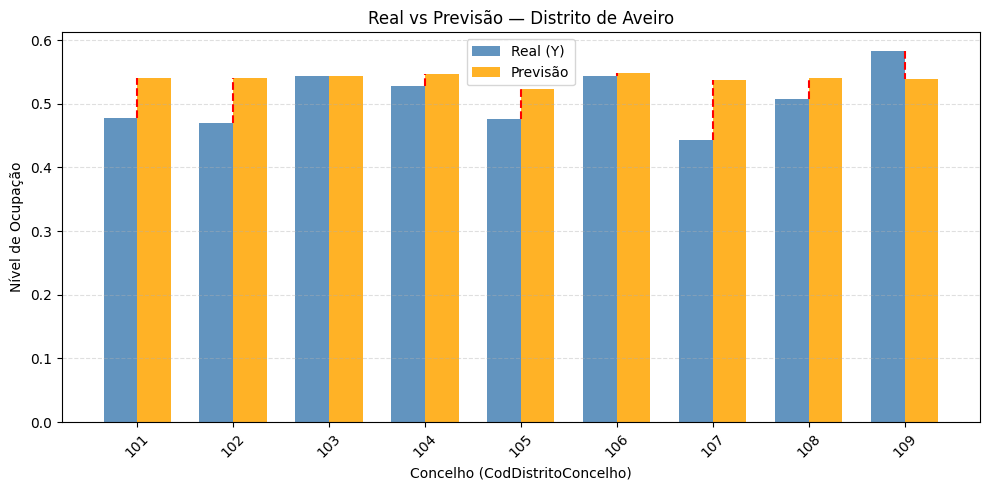

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(comparativo))
largura = 0.35

ax.bar(x - largura/2, comparativo['Real (Y)'],  largura, label='Real (Y)',   color='steelblue', alpha=0.85)
ax.bar(x + largura/2, comparativo['Previsão'],   largura, label='Previsão',  color='orange',    alpha=0.85)

# Linha de erro para visualizar o resíduo
for i, (real, prev) in enumerate(zip(comparativo['Real (Y)'], comparativo['Previsão'])):
    ax.plot([i, i], [real, prev], color='red', linewidth=1.5, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(comparativo.index, rotation=45)
ax.set_xlabel('Concelho (CodDistritoConcelho)')
ax.set_ylabel('Nível de Ocupação')
ax.set_title('Real vs Previsão — Distrito de Aveiro')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 4.5.7

Utilize o modelo para identificar os concelhos onde a libertação de potência é estatisticamente mais viável para a instalação de carregadores de veículos elétricos de 22 kW, justificando com base nos intervalos de confiança das previsões.

In [57]:
# Identificar os concelhos onde a instalação de carregadores de 22 kW é estatisticamente mais viável
# Critério combinado:
#   1. Limite Superior IC 95% baixo — ocupação garantidamente baixa mesmo no pior cenário
#   2. Saldo Final de Viabilidade (D) positivo — a rede consegue absorver a carga dos VEs

pred_pedidas = modelo.get_prediction(X_com_const)
frame_pred   = pred_pedidas.summary_frame(alpha=0.05)

df_ve = pd.DataFrame({
    'Ocupação Prevista':   frame_pred['mean'],
    'Limite Superior 95%': frame_pred['obs_ci_upper'],
}, index=df_final.index).round(4)

# Juntar o Saldo Final de Viabilidade calculado no 4.2.3
df_ve = df_ve.join(resulting_data['Saldo Final de Viabilidade'])
df_ve['Concelho'] = df_ve.index.map(mapa_concelhos)

# Filtrar apenas concelhos com Saldo positivo (rede consegue absorver a carga VE)
df_ve_viavel = df_ve[df_ve['Saldo Final de Viabilidade'] > 0].copy()

# Ordenar pelo Limite Superior — dentro dos viáveis, os mais seguros primeiro
concelhos_viaveis = df_ve_viavel.sort_values(by='Limite Superior 95%').head(10)

tabela = concelhos_viaveis[['Concelho', 'Ocupação Prevista', 'Limite Superior 95%', 'Saldo Final de Viabilidade']].copy()
tabela['Saldo Final de Viabilidade'] = tabela['Saldo Final de Viabilidade'].round(1)
tabela.index.name = 'Código'

print("TOP 10 Concelhos mais viáveis para instalação de carregadores VE (22 kW):")
print(tabela.to_string())

melhor = concelhos_viaveis.iloc[0]
print(f"\nConcelho mais viável: {melhor['Concelho']}")
print(f"  Ocupação Prevista:      {melhor['Ocupação Prevista']:.4f}")
print(f"  Limite Superior 95%:    {melhor['Limite Superior 95%']:.4f}")
print(f"  Saldo de Viabilidade:   {melhor['Saldo Final de Viabilidade']:.1f} kVA")

NameError: name 'mapa_concelhos' is not defined

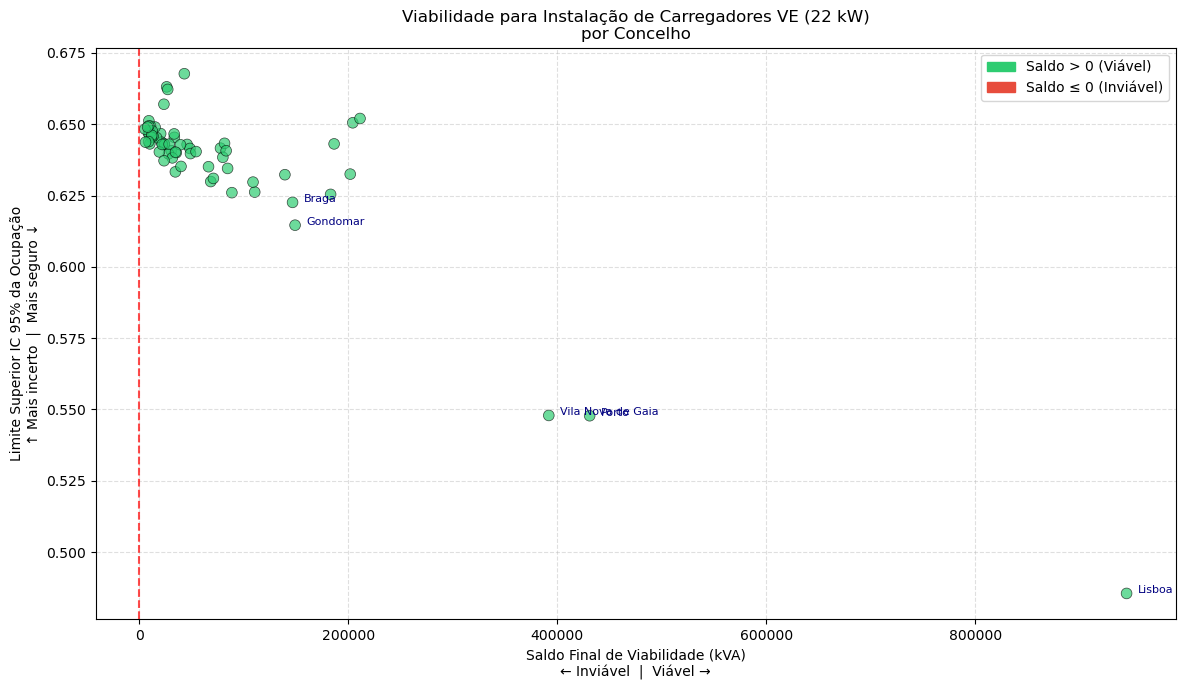

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Todos os concelhos com dados
df_plot = df_ve.dropna(subset=['Saldo Final de Viabilidade', 'Limite Superior 95%', 'Concelho'])

# Colorir por viabilidade
cores = df_plot['Saldo Final de Viabilidade'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')

ax.scatter(
    df_plot['Saldo Final de Viabilidade'],
    df_plot['Limite Superior 95%'],
    c=cores, alpha=0.7, edgecolors='k', linewidths=0.5, s=60
)

# Linha de referência: Saldo = 0
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Saldo = 0 (limite viabilidade)')

for _, row in concelhos_viaveis.head(5).iterrows():
    if pd.notna(row['Concelho']):
        ax.annotate(
            row['Concelho'],
            xy=(row['Saldo Final de Viabilidade'], row['Limite Superior 95%']),
            xytext=(8, 0), textcoords='offset points',
            fontsize=8, color='navy'
        )

from matplotlib.patches import Patch
legenda = [
    Patch(color='#2ecc71', label='Saldo > 0 (Viável)'),
    Patch(color='#e74c3c', label='Saldo ≤ 0 (Inviável)'),
]
ax.legend(handles=legenda, loc='upper right')

ax.set_xlabel('Saldo Final de Viabilidade (kVA)\n← Inviável  |  Viável →')
ax.set_ylabel('Limite Superior IC 95% da Ocupação\n↑ Mais incerto  |  Mais seguro ↓')
ax.set_title('Viabilidade para Instalação de Carregadores VE (22 kW)\npor Concelho')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 4.6 - Análise e Discussão de Resultados

Efetue uma síntese dos resultados e das conclusões, obtidos neste trabalho, que considera mais importantes, justificando sempre que necessário (conclusão). Use um nível de significância de 5% em todos os testes de hipótese que realizar.